# Inverse Yield Modeling For A Fixed Crop

This notebook demonstrates a first robust inverse-modeling workflow for the Manitoba yield project.

It does four things:
1. loads the engineered tabular climate features,
2. trains a fixed-crop regression model in scaled numeric feature space,
3. uses `inverse_yield(...)` to recover plausible climate vectors for target yields,
4. summarizes how the recovered solutions compare with the empirical climate distribution.

Assumptions for this first version:
- crop is fixed externally and is **not** optimized,
- inversion is done in the **same scaled numeric feature space** used by the regression model,
- only engineered climate features are inverted here,
- `Year`, `Latitude`, `Longitude`, `Municipality`, and `Crop` are excluded from inversion to keep the task focused on climate descriptors.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'Manitoba').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MANITOBA_DIR = PROJECT_ROOT / 'Manitoba'
if str(MANITOBA_DIR) not in sys.path:
    sys.path.insert(0, str(MANITOBA_DIR))

from inverse_modeling import inverse_yield, estimate_empirical_reference

plt.style.use('ggplot')
np.set_printoptions(suppress=True, precision=4)

DATA_PATH = MANITOBA_DIR / 'prepared' / 'yields_weather_by_crop.csv'
RANDOM_STATE = 42
CROP = 'RED SPRING WHEAT'
TEST_SIZE = 0.2


In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head(3)


(4864, 78)


,Year,Municipality,Crop,Mean_Yield,05_Q1_CDD,05_Q2_CDD,06_Q1_CDD,06_Q2_CDD,07_Q1_CDD,07_Q2_CDD,...,07_Q1_Ptol,07_Q2_Ptol,08_Q1_Ptol,08_Q2_Ptol,09_Q1_Ptol,09_Q2_Ptol,10_Q1_Ptol,10_Q2_Ptol,Latitude,Longitude
0,1996,ALEXANDER,ARGENTINE CANOLA,0.728428,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042,50.6667,-96.5
1,1996,ALEXANDER,OATS,1.215000,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042,50.6667,-96.5
2,1996,ALONSA,ALFALFA/GRASS MIX.,1.609253,0.0,2.014729,37.197368,35.920028,39.128350,18.739317,...,0.058935,0.080042,0.030213,0.010850,0.033199,0.015887,0.017048,0.052276,NaN,NaN


In [3]:
# Climate-only engineered features: the prepared table uses names like '05_Q1_CDD'.
import re

climate_feature_cols = [
    c for c in df.columns
    if re.match(r'^\d{2}_Q[12]_', c)
]

fixed_crop_df = (
    df.loc[df['Crop'] == CROP, ['Mean_Yield', 'Crop'] + climate_feature_cols]
      .dropna()
      .reset_index(drop=True)
)

print('Crop:', CROP)
print('Rows after filtering and dropping NA:', len(fixed_crop_df))
print('Number of climate features:', len(climate_feature_cols))
climate_feature_cols[:10]


Crop: RED SPRING WHEAT
Rows after filtering and dropping NA: 1088
Number of climate features: 72


['05_Q1_CDD',
 '05_Q2_CDD',
 '06_Q1_CDD',
 '06_Q2_CDD',
 '07_Q1_CDD',
 '07_Q2_CDD',
 '08_Q1_CDD',
 '08_Q2_CDD',
 '09_Q1_CDD',
 '09_Q2_CDD']

## Train A Simple Fixed-Crop Predictor

The project notebooks use standardized numeric inputs before fitting models such as MLP and GP.  
For this notebook, we train a compact `sklearn` MLP on the same kind of scaled numeric climate matrix so the inverse solver can be demonstrated end-to-end without depending on notebook-local training artifacts.


In [4]:
X = fixed_crop_df[climate_feature_cols].copy()
y = fixed_crop_df['Mean_Yield'].to_numpy(dtype=float)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    alpha=1e-3,
    learning_rate_init=1e-3,
    max_iter=800,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

metrics = pd.DataFrame([
    {
        'split': 'train',
        'rmse': mean_squared_error(y_train, y_train_pred) ** 0.5,
        'mae': mean_absolute_error(y_train, y_train_pred),
        'r2': r2_score(y_train, y_train_pred),
    },
    {
        'split': 'test',
        'rmse': mean_squared_error(y_test, y_test_pred) ** 0.5,
        'mae': mean_absolute_error(y_test, y_test_pred),
        'r2': r2_score(y_test, y_test_pred),
    },
])
metrics


,split,rmse,mae,r2
0,train,0.132671,0.100647,0.760625
1,test,0.179427,0.141765,0.535589


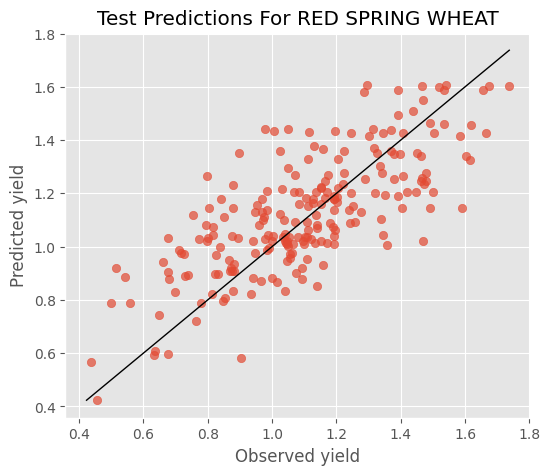

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test, y_test_pred, alpha=0.7)
lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, color='black', linewidth=1)
ax.set_title(f'Test Predictions For {CROP}')
ax.set_xlabel('Observed yield')
ax.set_ylabel('Predicted yield')
plt.show()


## Build Inverse Inputs

The inverse solver expects everything in model-input space.  
Since the MLP was trained on `StandardScaler` outputs, we invert in that same standardized space.


In [6]:
reference = estimate_empirical_reference(X_train)
reference_mean = reference['mean']
reference_cov = reference['cov']

# Bounds in scaled space from empirical training quantiles.
lower = np.quantile(X_train, 0.01, axis=0)
upper = np.quantile(X_train, 0.99, axis=0)
bounds = list(zip(lower, upper))

train_quantiles = pd.Series(y_train).quantile([0.25, 0.5, 0.75])
train_quantiles


0.25    0.927539
0.50    1.077944
0.75    1.258969
dtype: float64

In [7]:
targets = {
    'low': float(train_quantiles.loc[0.25]),
    'median': float(train_quantiles.loc[0.5]),
    'high': float(train_quantiles.loc[0.75]),
}

inverse_results = {}
for label, y_target in targets.items():
    inverse_results[label] = inverse_yield(
        model=model,
        y_target=y_target,
        feature_names=climate_feature_cols,
        bounds=bounds,
        reference_mean=reference_mean,
        reference_cov=reference_cov,
        lambda_mahal=0.0,
        lambda_l2=0.001,
        n_restarts=8,
        random_state=RANDOM_STATE,
    )

summary_rows = []
for label, result in inverse_results.items():
    summary_rows.append({
        'scenario': label,
        'y_target': result['y_target'],
        'y_pred': result['y_pred'],
        'abs_error': abs(result['y_pred'] - result['y_target']),
        'objective_value': result['objective_value'],
        'success': result['success'],
        'message': result['message'],
    })

inverse_summary = pd.DataFrame(summary_rows)
inverse_summary


,scenario,y_target,y_pred,abs_error,objective_value,success,message
0,low,0.927539,0.926530,0.001009,0.000541,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
1,median,1.077944,1.076334,0.001610,0.000901,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...
2,high,1.258969,1.257114,0.001854,0.001489,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...


## Regularization Sensitivity

Inverse solutions are not unique.  
A practical question is how much regularization is needed before the optimizer starts trading target accuracy for plausibility.

The next cell compares three settings for the **high-yield** target:
- no regularization,
- weak L2 regularization around the empirical mean,
- Mahalanobis + L2 regularization.


In [8]:
sensitivity_settings = [
    {'name': 'none', 'lambda_mahal': 0.0, 'lambda_l2': 0.0},
    {'name': 'weak_l2', 'lambda_mahal': 0.0, 'lambda_l2': 0.001},
    {'name': 'mahal_plus_l2', 'lambda_mahal': 0.01, 'lambda_l2': 0.001},
]

sensitivity_rows = []
high_target = targets['high']
for setting in sensitivity_settings:
    result = inverse_yield(
        model=model,
        y_target=high_target,
        feature_names=climate_feature_cols,
        bounds=bounds,
        reference_mean=reference_mean,
        reference_cov=reference_cov,
        lambda_mahal=setting['lambda_mahal'],
        lambda_l2=setting['lambda_l2'],
        n_restarts=6,
        random_state=RANDOM_STATE,
    )
    sensitivity_rows.append({
        'setting': setting['name'],
        'lambda_mahal': setting['lambda_mahal'],
        'lambda_l2': setting['lambda_l2'],
        'y_target': high_target,
        'y_pred': result['y_pred'],
        'abs_error': abs(result['y_pred'] - high_target),
        'objective_value': result['objective_value'],
        'success': result['success'],
    })

pd.DataFrame(sensitivity_rows)


,setting,lambda_mahal,lambda_l2,y_target,y_pred,abs_error,objective_value,success
0,none,0.00,0.000,1.258969,1.258969,4.352074e-14,1.894055e-27,True
1,weak_l2,0.00,0.001,1.258969,1.257114,1.854162e-03,1.488564e-03,True
2,mahal_plus_l2,0.01,0.001,1.258969,0.966651,2.923175e-01,1.515221e+00,True


## Inspect The Recovered Climate Vectors

The next cells transform the optimized vectors back to the original climate-feature scale and compare them with the empirical mean climate for the selected crop.


In [9]:
raw_reference_mean = scaler.inverse_transform(reference_mean.reshape(1, -1)).ravel()
raw_reference_mean_series = pd.Series(raw_reference_mean, index=climate_feature_cols)

raw_solutions = {}
for label, result in inverse_results.items():
    raw_x = scaler.inverse_transform(result['x_opt'].reshape(1, -1)).ravel()
    raw_solutions[label] = pd.Series(raw_x, index=climate_feature_cols)

comparison = pd.DataFrame({
    'reference_mean': raw_reference_mean_series,
    **{f'{label}_solution': series for label, series in raw_solutions.items()},
})
comparison.head()


,reference_mean,low_solution,median_solution,high_solution
05_Q1_CDD,0.441641,0.506121,0.528900,0.552530
05_Q2_CDD,2.726653,2.390821,2.262278,2.193027
06_Q1_CDD,8.186587,8.688472,8.738354,8.914573
06_Q2_CDD,23.020649,21.503042,21.351700,20.969417
07_Q1_CDD,35.134246,36.901201,37.513228,38.364683


In [10]:
def top_feature_shifts(result, top_k=12):
    delta_scaled = result['x_opt'] - reference_mean
    shift = pd.Series(delta_scaled, index=climate_feature_cols)
    out = pd.DataFrame({
        'feature': shift.index,
        'scaled_shift_from_mean': shift.values,
        'abs_scaled_shift': np.abs(shift.values),
        'raw_reference_mean': raw_reference_mean_series.reindex(shift.index).values,
        'raw_solution': scaler.inverse_transform(result['x_opt'].reshape(1, -1)).ravel(),
    })
    out['raw_delta'] = out['raw_solution'] - out['raw_reference_mean']
    return out.sort_values('abs_scaled_shift', ascending=False).head(top_k)

for label, result in inverse_results.items():
    print(f'\nScenario: {label}')
    display(top_feature_shifts(result))



Scenario: low


,feature,scaled_shift_from_mean,abs_scaled_shift,raw_reference_mean,raw_solution,raw_delta
33,09_Q2_Max_Temp,0.219920,0.219920,16.132969,16.693843,0.560874
55,08_Q2_Min_Temp,0.210396,0.210396,13.797274,14.134643,0.337369
61,05_Q2_Ptol,-0.202762,0.202762,0.044199,0.037928,-0.006272
23,10_Q2_HDD,-0.189303,0.189303,228.497754,220.540869,-7.956884
44,09_Q1_Mean_Temp,-0.182480,0.182480,15.627882,15.215165,-0.412716
9,09_Q2_CDD,-0.146335,0.146335,3.412839,2.707695,-0.705144
12,05_Q1_HDD,-0.139921,0.139921,142.539193,137.330686,-5.208507
47,10_Q2_Mean_Temp,-0.126515,0.126515,3.718890,3.386532,-0.332359
28,07_Q1_Max_Temp,-0.125778,0.125778,24.199425,23.957739,-0.241686
64,07_Q1_Ptol,-0.124019,0.124019,0.045277,0.041905,-0.003372



Scenario: median


,feature,scaled_shift_from_mean,abs_scaled_shift,raw_reference_mean,raw_solution,raw_delta
33,09_Q2_Max_Temp,0.277280,0.277280,16.132969,16.840130,0.707161
55,08_Q2_Min_Temp,0.259053,0.259053,13.797274,14.212664,0.415390
44,09_Q1_Mean_Temp,-0.250387,0.250387,15.627882,15.061580,-0.566302
23,10_Q2_HDD,-0.249394,0.249394,228.497754,218.015125,-10.482629
61,05_Q2_Ptol,-0.212633,0.212633,0.044199,0.037622,-0.006577
9,09_Q2_CDD,-0.198706,0.198706,3.412839,2.455337,-0.957502
12,05_Q1_HDD,-0.195046,0.195046,142.539193,135.278671,-7.260522
7,08_Q2_CDD,0.172128,0.172128,27.646186,30.545524,2.899337
52,07_Q1_Min_Temp,0.171662,0.171662,14.909239,15.174928,0.265689
47,10_Q2_Mean_Temp,-0.160647,0.160647,3.718890,3.296866,-0.422025



Scenario: high


,feature,scaled_shift_from_mean,abs_scaled_shift,raw_reference_mean,raw_solution,raw_delta
44,09_Q1_Mean_Temp,-0.406370,0.406370,15.627882,14.708791,-0.919090
55,08_Q2_Min_Temp,0.367858,0.367858,13.797274,14.387132,0.589858
33,09_Q2_Max_Temp,0.312943,0.312943,16.132969,16.931084,0.798115
23,10_Q2_HDD,-0.287139,0.287139,228.497754,216.428614,-12.069139
28,07_Q1_Max_Temp,-0.240938,0.240938,24.199425,23.736455,-0.462970
64,07_Q1_Ptol,-0.230664,0.230664,0.045277,0.039006,-0.006271
27,06_Q2_Max_Temp,0.217636,0.217636,22.588422,23.033687,0.445265
61,05_Q2_Ptol,-0.214901,0.214901,0.044199,0.037552,-0.006647
54,08_Q1_Min_Temp,0.212259,0.212259,14.927183,15.273264,0.346081
45,09_Q2_Mean_Temp,0.212158,0.212158,12.189921,12.627488,0.437567


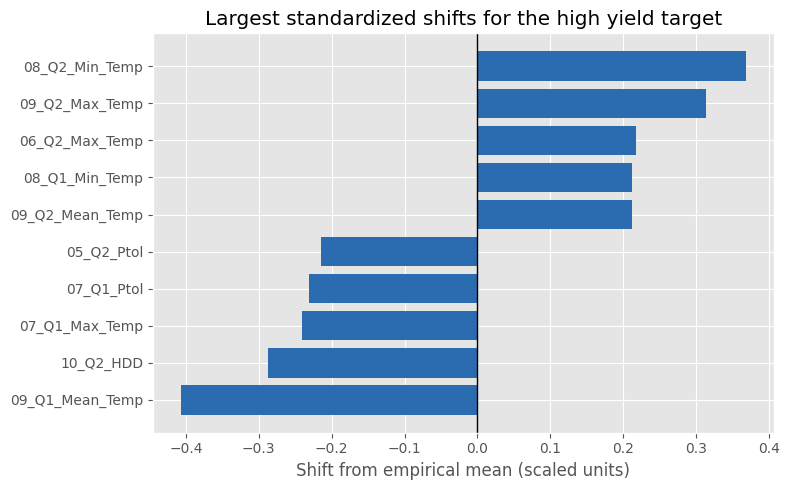

In [11]:
plot_label = 'high'
plot_df = top_feature_shifts(inverse_results[plot_label], top_k=10).sort_values('scaled_shift_from_mean')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df['feature'], plot_df['scaled_shift_from_mean'], color='#2b6cb0')
ax.axvline(0.0, color='black', linewidth=1)
ax.set_title(f'Largest standardized shifts for the {plot_label} yield target')
ax.set_xlabel('Shift from empirical mean (scaled units)')
plt.tight_layout()
plt.show()


In [12]:
restart_diagnostics = []
for label, result in inverse_results.items():
    for restart in result['restart_summaries']:
        restart_diagnostics.append({
            'scenario': label,
            'restart': restart['restart'],
            'objective_value': restart['objective_value'],
            'y_pred': restart['y_pred'],
            'success': restart['success'],
        })

restart_df = pd.DataFrame(restart_diagnostics)
restart_df.groupby('scenario')[['objective_value', 'y_pred']].agg(['min', 'median', 'max'])


objective_value                        y_pred                    
                     min    median       max       min    median       max
scenario                                                                  
high            0.001489  0.001693  0.002364  1.256353  1.257015  1.257325
low             0.000541  0.000679  0.000952  0.925848  0.926171  0.926530
median          0.000901  0.001368  0.002131  1.075474  1.075900  1.076509

## Interpretation

What to look for in the tables above:
- `abs_error` shows how closely inversion matched the requested target yield.
- `objective_value` combines prediction error and regularization penalties.
- `scaled_shift_from_mean` highlights which climate features must move the most relative to the empirical crop-specific climate distribution.
- Large shifts near the chosen bounds usually indicate the requested target yield is hard to realize without leaving the observed climate manifold.

For project use, the natural next step is to replace the demonstration MLP in this notebook with the actual trained MLP or GP object from the corresponding training notebook, while keeping inversion in the exact processed numeric feature space used during training.
